<a href="https://colab.research.google.com/github/ftkals/Digital-News-Bias-Analyzer/blob/main/Staiml_MiniProject_Py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. LOAD DATA
master = pd.read_csv("/content/drive/MyDrive/staiml mini project/Headline_Master.csv")
meta = pd.read_csv("/content/drive/MyDrive/staiml mini project/Source_Metadata.csv")

In [ ]:
# 2. LINGUISTIC ANALYSIS (Basics: Loops & If-Else)
# We define "Ethical" and "Unethical" keywords manually
negative_words = ['crisis', 'stall', 'delay', 'disband', 'decline', 'attack']
positive_words = ['growth', 'launch', 'startup', 'strategy', 'ambition']

tone_list = []

# Loop through each headline
for headline in master['Headline_Text']:
    headline = headline.lower() # Basic string cleaning

    # Check for keywords
    if any(word in headline for word in negative_words):
        tone_list.append('Negative')
    elif any(word in headline for word in positive_words):
        tone_list.append('Positive')
    else:
        tone_list.append('Neutral')

# Add the results back to our table
master['Forensic_Tone'] = tone_list

In [ ]:
# 3. MERGING (Joining the two sheets)
# This combines headline data with source info (Region/Media Type)
final_df = pd.merge(master, meta, on="Source_Name")

In [ ]:
# 4. MEANINGFUL INSIGHTS
# Grouping to see which Tone gets more Reach
insight = final_df.groupby('Forensic_Tone')['Reach_Percentage'].mean()
print("Average Reach by Tone:")
print(insight)

Average Reach by Tone:
Forensic_Tone
Negative    0.385500
Neutral     0.485328
Positive    0.273067
Name: Reach_Percentage, dtype: float64


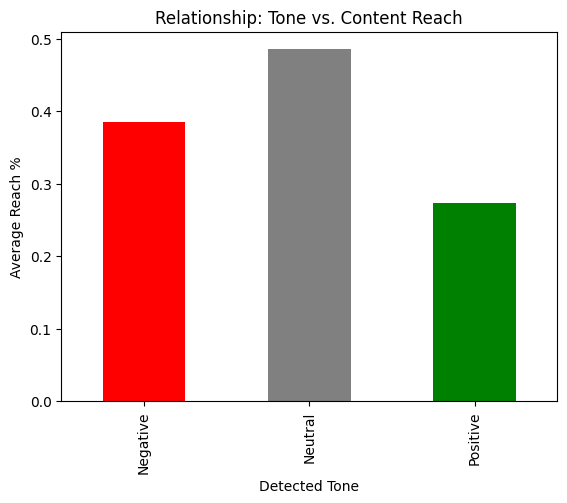

In [ ]:
# 5. VISUALIZATION (Basic Bar Chart)
insight.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title("Relationship: Tone vs. Content Reach")
plt.ylabel("Average Reach %")
plt.xlabel("Detected Tone")
plt.show()

In [ ]:
# Find the Top 5 headlines with the highest Impact Score
top_impact = master.nlargest(5, 'Impact_Score')

# Display specific columns to show the 'Winners'
print("--- THE MOST IMPACTFUL HEADLINES ---")
top_impact[['Headline_Text', 'Source_Name', 'Impact_Score']]

--- THE MOST IMPACTFUL HEADLINES ---


,Headline_Text,Source_Name,Impact_Score
48,ETS2 Frontloading Facility Approved by Europea...,European Commission,22176
45,EU Marks 75 Years Since Treaty of Paris Establ...,European Commission,21249
41,EU Immunization Week 2026: Three Countries Rea...,European Commission,20664
17,Activist Groups in 24 States Protest AI Data C...,TechCrunch,19184
7,Blue Origin's New Glenn Rocket Successfully Re...,TechCrunch,18664


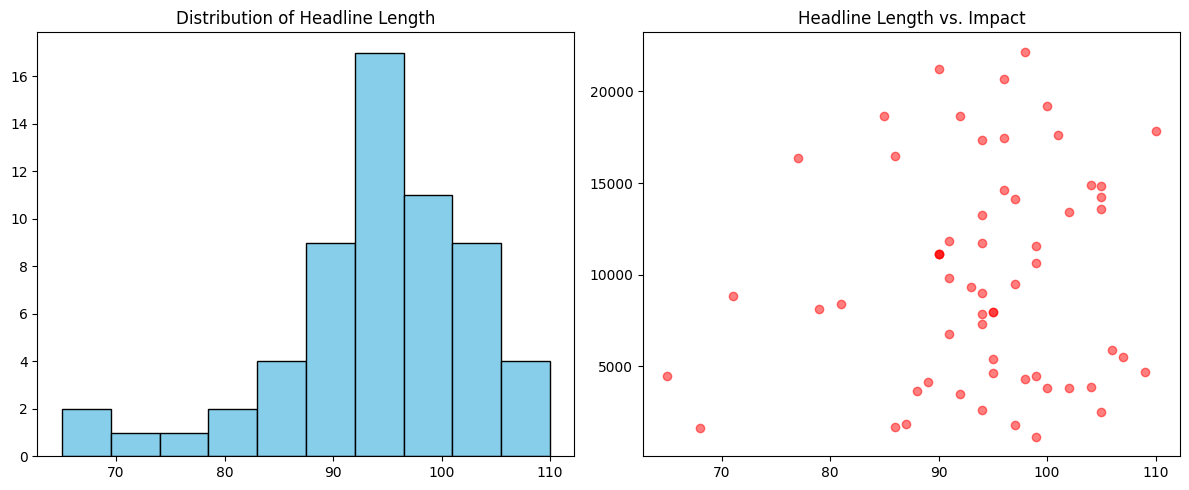

In [ ]:
# Create a figure with 1 row and 2 columns
plt.figure(figsize=(12, 5))

# Plot 1: Histogram of Headline Length
plt.subplot(1, 2, 1)
plt.hist(master['Headline_Length'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Headline Length")

# Plot 2: Scatterplot of Length vs Impact
plt.subplot(1, 2, 2)
plt.scatter(master['Headline_Length'], master['Impact_Score'], alpha=0.5, color='red')
plt.title("Headline Length vs. Impact")

plt.tight_layout()
plt.show()

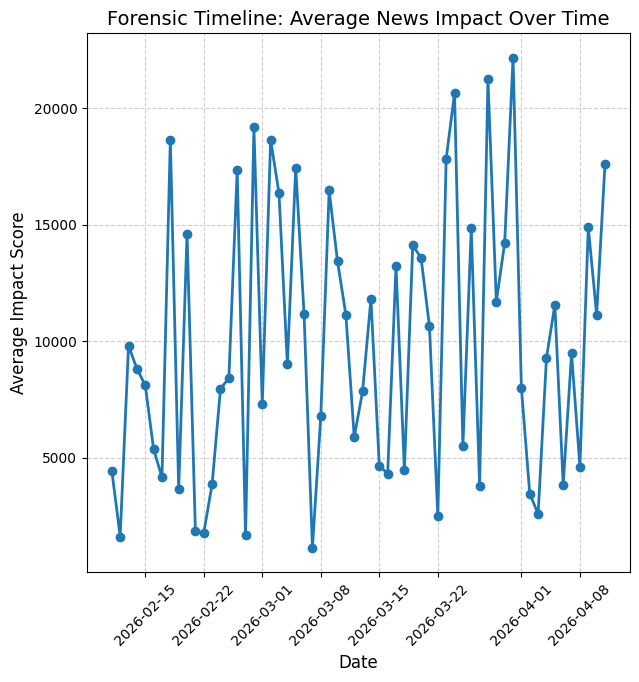

In [ ]:
# Convert the 'Date' column to actual Python dates
master['Date'] = pd.to_datetime(master['Date'])

# Group by Date to see the daily average to create a "Time Series" of your data
daily_trend = master.groupby('Date')['Impact_Score'].mean()

# Create the Line Plot
plt.figure(figsize=(7, 7))

# Plotting the line
plt.plot(daily_trend.index, daily_trend.values,
         marker='o',          # Adds dots at each day
         linestyle='-',       # Connects them with a line
         linewidth=2)

plt.title("Forensic Timeline: Average News Impact Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Impact Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Makes it easier to read
plt.xticks(rotation=45) # Tilts dates so they don't overlap

plt.show()

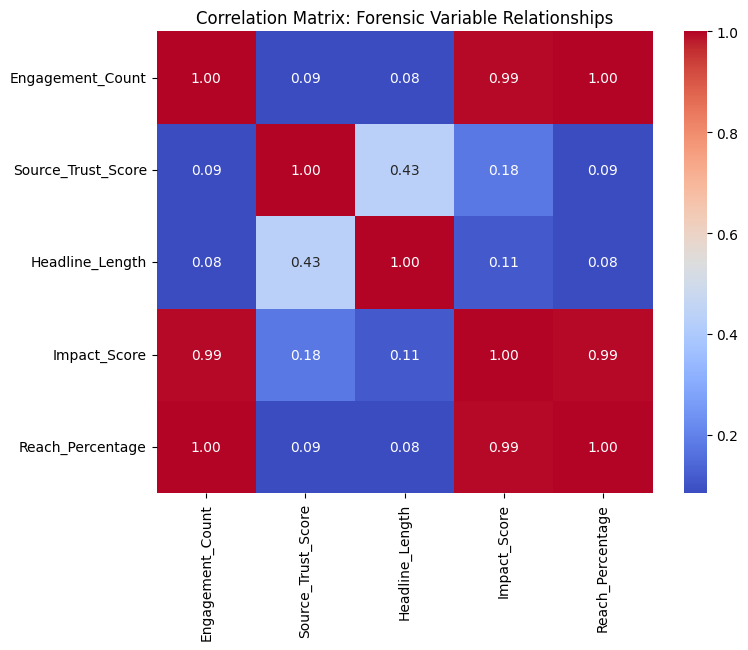

In [ ]:
# Select only the numeric columns
numeric_data = master[['Engagement_Count', 'Source_Trust_Score',
                       'Headline_Length', 'Impact_Score', 'Reach_Percentage']]

# Calculate Correlation
correlation_matrix = numeric_data.corr()

# Visualize as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Forensic Variable Relationships")
plt.show()

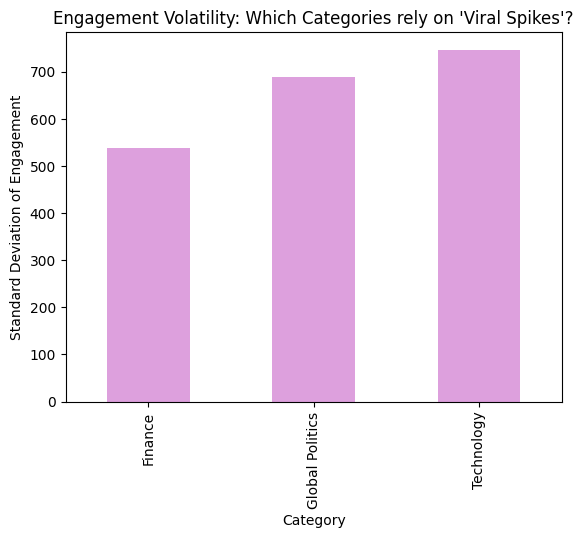

In [ ]:
# Use NumPy to find the Standard Deviation (Volatility) of Engagement per Category
volatility = master.groupby('Category')['Engagement_Count'].apply(np.std)

# A high bar here means the category is "Unstable"
volatility.plot(kind='bar', color='plum')
plt.title("Engagement Volatility: Which Categories rely on 'Viral Spikes'?")
plt.ylabel("Standard Deviation of Engagement")
plt.show()

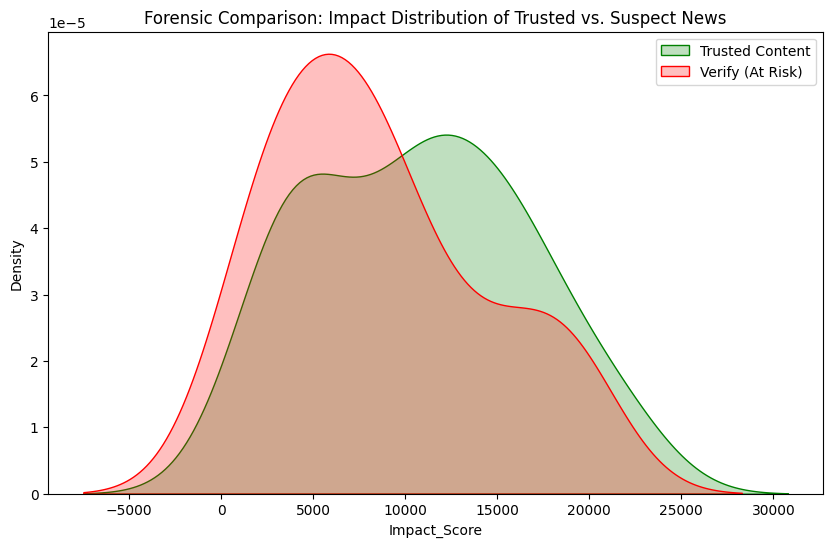

In [ ]:
plt.figure(figsize=(10, 6))

# Plot two distributions on the same graph
sns.kdeplot(master[master['Reliability_Check'] == 'Trusted']['Impact_Score'],
            label='Trusted Content', fill=True, color="green")
sns.kdeplot(master[master['Reliability_Check'] == 'Verify']['Impact_Score'],
            label='Verify (At Risk)', fill=True, color="red")
# A KDE (Kernel Density Estimate) plot is a way to visualize the probability density function of a continuous variable. It's used to represent the distribution of data, similar to a histogram, but with a smooth curve instead of bars
plt.title("Forensic Comparison: Impact Distribution of Trusted vs. Suspect News")
plt.legend()
plt.show()

## 6. Model Training

In [ ]:
# Redefine features (X) and target (y) for Impact_Score prediction

y_reg = df_filtered['Impact_Score']
X_reg = df_filtered[['Headline_Length', 'Engagement_Count', 'Source_Trust_Score', 'Category', 'Forensic_Tone', 'Reliability_Check']]

# Define numerical and categorical features for the regression task
numerical_features_reg = ['Headline_Length', 'Engagement_Count', 'Source_Trust_Score']
categorical_features_reg = ['Category', 'Forensic_Tone', 'Reliability_Check']

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("New features and target defined for regression.")

New features and target defined for regression.


In [ ]:
# Preprocess features using one-hot encoding and combine them for model training.
# Initialize and apply OneHotEncoder to categorical features
onehot_reg = OneHotEncoder(handle_unknown='ignore') #The handle_unknown='ignore' parameter tells the OneHotEncoder to simply output all zeros for any categorical value it encounters in the test set that it did not see during training.

X_train_cat_encoded_reg = onehot_reg.fit_transform(X_train_reg[categorical_features_reg])
X_test_cat_encoded_reg = onehot_reg.transform(X_test_reg[categorical_features_reg])

# np.hstack is used to horizontally stack arrays, combining numerical and encoded categorical features.
# .toarray() converts the sparse matrix output by OneHotEncoder to a dense NumPy array.
X_train_processed_reg = np.hstack([X_train_reg[numerical_features_reg].values, X_train_cat_encoded_reg.toarray()])
X_test_processed_reg = np.hstack([X_test_reg[numerical_features_reg].values, X_test_cat_encoded_reg.toarray()])

print("Data preprocessing for regression complete. Training and testing sets are ready.")

Data preprocessing for regression complete. Training and testing sets are ready.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Initialize and train the Linear Regression model
model_lr_reg = LinearRegression()
model_lr_reg.fit(X_train_processed_reg, y_train_reg)

print("Linear Regression model trained successfully.")

# Make predictions on the test set
y_pred_lr_reg = model_lr_reg.predict(X_test_processed_reg)

# Evaluate the Linear Regression model
rmse_lr_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg))
mae_lr_reg = mean_absolute_error(y_test_reg, y_pred_lr_reg)

print("\nLinear Regression Model Evaluation:")
print(f"RMSE: {rmse_lr_reg:.2f}")
print(f"MAE: {mae_lr_reg:.2f}")

Linear Regression model trained successfully.

Linear Regression Model Evaluation:
RMSE: 368.19
MAE: 318.92


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
model_rf_reg = RandomForestRegressor(random_state=42)
model_rf_reg.fit(X_train_processed_reg, y_train_reg)

print("Random Forest Regressor model trained successfully.")

# Make predictions on the test set
y_pred_rf_reg = model_rf_reg.predict(X_test_processed_reg)

# Evaluate the Random Forest Regressor model
rmse_rf_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
mae_rf_reg = mean_absolute_error(y_test_reg, y_pred_rf_reg)

print("\nRandom Forest Regressor Model Evaluation:")
print(f"RMSE: {rmse_rf_reg:.2f}")
print(f"R-squared: {mae_rf_reg:.2f}")

Random Forest Regressor model trained successfully.

Random Forest Regressor Model Evaluation:
RMSE: 860.85
R-squared: 575.96


In [ ]:
print("\n--- Regression Model Comparison ---")
print(f"Linear Regression - RMSE: {rmse_lr_reg:.2f}, R-squared: {mae_lr_reg:.2f}")
print(f"Random Forest Regressor - RMSE: {rmse_rf_reg:.2f}, R-squared: {mae_rf_reg:.2f}")


--- Regression Model Comparison ---
Linear Regression - RMSE: 368.19, R-squared: 318.92
Random Forest Regressor - RMSE: 860.85, R-squared: 575.96


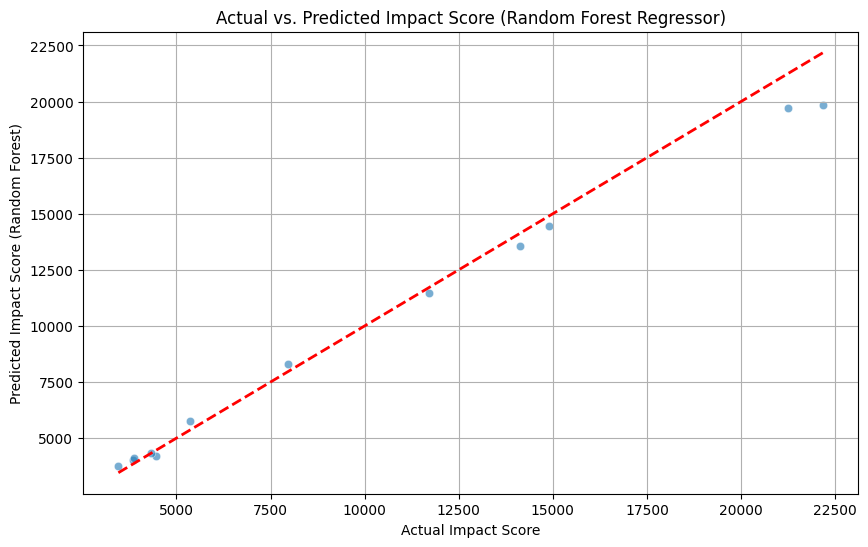

In [ ]:
# Visualize predictions vs actuals for the better model (likely Random Forest)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_rf_reg, alpha=0.6)
# Plot an ideal line (where Predicted = Actual) for visual comparison
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel("Actual Impact Score")
plt.ylabel("Predicted Impact Score (Random Forest)")
plt.title("Actual vs. Predicted Impact Score (Random Forest Regressor)")
plt.grid(True)
plt.show()

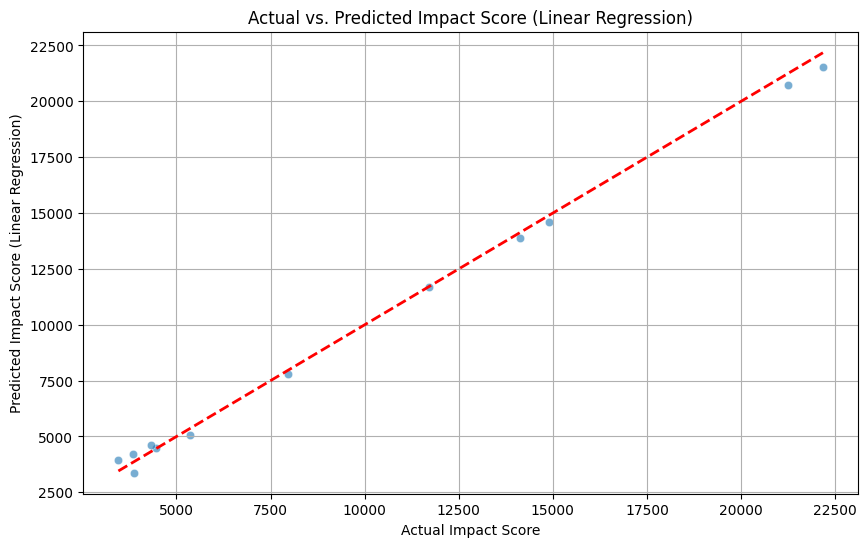

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_lr_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2) # Ideal line
plt.xlabel("Actual Impact Score")
plt.ylabel("Predicted Impact Score (Linear Regression)")
plt.title("Actual vs. Predicted Impact Score (Linear Regression)")
plt.grid(True)
plt.show()